# Exploratory Data Analysis

# 1. Objective

Analyze the SDSS 17 Stellar Classification, understand the structure, schema, data type and basic statistical properties of the dataset. At the same time, identifying potential data quality issues.

# 2. Dataset Overview

## Context

Stellar Classification, in Astronomy, is the classification of stars based on their spectral characteristics. This dataset aims to classify stars, galaxies, and quasars based on their spectral characteristics.

## Data Dictionary

- *obj_ID:* Object Identifier, the unique value that identifies the object in the image catalog used by the CAS
- *alpha:* Right Ascension angle (at J2000 epoch)
- *delta:* Declination angle (at J2000 epoch)
- *u:* Ultraviolet filter in the photometric system
- *g:* Green filter in the photometric system
- *r:* Red filter in the photometric system
- *i:* Near Infrared filter in the photometric system
- *z:* Infrared filter in the photometric system
- *run_ID:* Run Number used to identify the specific scan
- *rereun_ID:* Rerun Number to specify how the image was processed
- *cam_col:* Camera column to identify the scanline within the run
- *field_ID:* Field number to identify each field
- *spec_obj_ID:* Unique ID used for optical spectroscopic objects (this means that 2 different observations with the same spec_obj_ID must share the output class)
- *class:* object class (galaxy, star or quasar object)
- *redshift:* redshift value based on the increase in wavelength
- *plate:* plate ID, identifies each plate in SDSS
- *MJD:* Modified Julian Date, used to indicate when a given piece of SDSS data was taken
- *fiber_ID:* fiber ID that identifies the fiber that pointed the light at the focal plane in each observation

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
import sys

from pyprojroot import here

sys.path.append(str(here()))

from src.exist.config import DATA_PATH
from src.exist.utils import plot_box, plot_histogram

In [3]:
df = pd.read_csv(DATA_PATH)

In [4]:
df.head()

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842


In [5]:
df.shape

(100000, 18)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   alpha        100000 non-null  float64
 2   delta        100000 non-null  float64
 3   u            100000 non-null  float64
 4   g            100000 non-null  float64
 5   r            100000 non-null  float64
 6   i            100000 non-null  float64
 7   z            100000 non-null  float64
 8   run_ID       100000 non-null  int64  
 9   rerun_ID     100000 non-null  int64  
 10  cam_col      100000 non-null  int64  
 11  field_ID     100000 non-null  int64  
 12  spec_obj_ID  100000 non-null  float64
 13  class        100000 non-null  str    
 14  redshift     100000 non-null  float64
 15  plate        100000 non-null  int64  
 16  MJD          100000 non-null  int64  
 17  fiber_ID     100000 non-null  int64  
dtypes: float64(10), int64(7), str(1)
mem

In [7]:
df.describe()

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,redshift,plate,MJD,fiber_ID
count,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.0,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000
mean,1.237665e+18,177.629117,24.135305,21.980468,20.531387,19.645762,19.084854,18.668810,4481.366060,301.0,3.511610,186.130520,5.783882e+18,0.576661,5137.009660,55588.647500,449.312740
std,8.438560e+12,96.502241,19.644665,31.769291,31.750292,1.854760,1.757895,31.728152,1964.764593,0.0,1.586912,149.011073,3.324016e+18,0.730707,2952.303351,1808.484233,272.498404
min,1.237646e+18,0.005528,-18.785328,-9999.000000,-9999.000000,9.822070,9.469903,-9999.000000,109.000000,301.0,1.000000,11.000000,2.995191e+17,-0.009971,266.000000,51608.000000,1.000000
25%,1.237659e+18,127.518222,5.146771,20.352353,18.965230,18.135828,17.732285,17.460677,3187.000000,301.0,2.000000,82.000000,2.844138e+18,0.054517,2526.000000,54234.000000,221.000000
50%,1.237663e+18,180.900700,23.645922,22.179135,21.099835,20.125290,19.405145,19.004595,4188.000000,301.0,4.000000,146.000000,5.614883e+18,0.424173,4987.000000,55868.500000,433.000000
75%,1.237668e+18,233.895005,39.901550,23.687440,22.123767,21.044785,20.396495,19.921120,5326.000000,301.0,5.000000,241.000000,8.332144e+18,0.704154,7400.250000,56777.000000,645.000000
max,1.237681e+18,359.999810,83.000519,32.781390,31.602240,29.571860,32.141470,29.383740,8162.000000,301.0,6.000000,989.000000,1.412694e+19,7.011245,12547.000000,58932.000000,1000.000000


### What is important here: 

After a basic overview of the data, the follow conclusions can be made:
- The data is relatively easy to handle with.
- The dataset contains additional metadata and identifier columns that are not relevant to the objectives of this analysis. These variables are therefore excluded from future analysis.
- The columns that will be used in the future analysis are the five photometric bands(**u**, **g**, **r**, **i**, **z**), **redshift** and **class**, as these variables directly represent the measurements relevant to the classification task. 

# 3. Data Quality

In [8]:
quality = pd.DataFrame(
    {
        "dtype": df.dtypes,
        "unique_values": df.nunique(),
        "null_count": df.isna().sum(),
        "sentinel_-9999_count": (df == -9999).sum(),
    }
)

In [9]:
quality

,dtype,unique_values,null_count,sentinel_-9999_count
obj_ID,float64,78053,0,0
alpha,float64,99999,0,0
delta,float64,99999,0,0
u,float64,93748,0,1
g,float64,92651,0,1
r,float64,91901,0,0
i,float64,92019,0,0
z,float64,92007,0,1
run_ID,int64,430,0,0
rerun_ID,int64,1,0,0


### Data quality decisions:

- The sentinel values (`-9999`) were detected in **u**, **g** and **z**. These values are outside the expected range and will need special treatment in the data cleaning stage.
- The type of the photometric value and redshift are correct. Therefore, no changes to the type of those collums.
- The type of **class** collumn will be changed from `str` to `category` during the data cleaning stage. It is a categorical variable, so the `category` type fits better.

# 4. Variable Analysis

In [10]:
features = ["u", "g", "r", "i", "z", "redshift"]
target = "class"

analysis_df = df[features + [target]].copy()
analysis_df[features] = analysis_df[features].replace(-9999, np.nan)

## 4.1 Target Variable

### 4.1.1 Class Distribution

The first step is to analyze the distribution of the target variable and verify whether the classes are balanced.

The target variable contains three classes (GALAXY, STAR and QSO). The class distribution should be examined to determine if the classes are distributed equally or is an unbalanced distribution between classes.

In [11]:
analysis_df["class"].value_counts(normalize=True)

class
GALAXY    0.59445
STAR      0.21594
QSO       0.18961
Name: proportion, dtype: float64

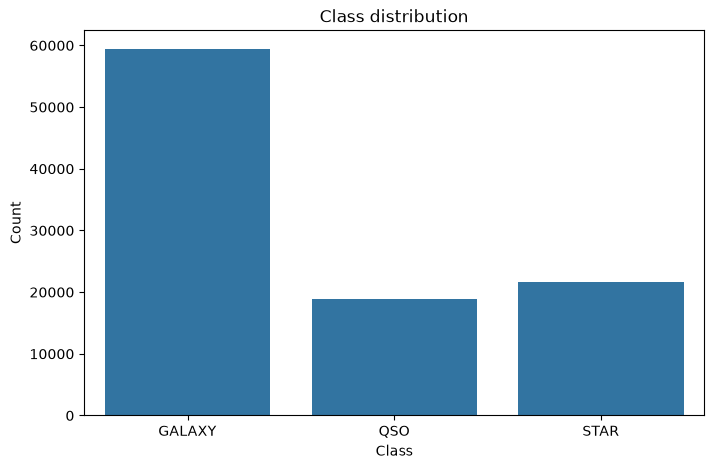

In [12]:
plt.figure(figsize=(8, 5))

sns.countplot(data=analysis_df, x="class")

plt.title("Class distribution")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

#### Conclusions about class:

The dataset is imbalanced, with GALAXY representing the majority of observations, while STAR and QSO have smaller proportions.

## 4.2 Univariate Analysis

### 4.2.1 Photometric Values

Photometric values measure visible light adjusted to match how the human eye perceives brightness.
Remember the dictionary:

- u: Ultraviolet filter in the photometric system
- g: Green filter in the photometric system
- r: Red filter in the photometric system
- i: Near Infrared filter in the photometric system
- z: Infrared filter in the photometric system

In each variable the following questions will be answered:
- What is its range?
- Where are values concentrated?
- Is the distribution symetric? If not, for what side is the tail?
- Are there potential outliers?

#### u - Ultraviolet filter:

In [13]:
analysis_df["u"].describe()

count    99999.000000
mean        22.080679
std          2.251068
min         10.996230
25%         20.352410
50%         22.179140
75%         23.687480
max         32.781390
Name: u, dtype: float64

In [14]:
analysis_df["u"].skew()

np.float64(-0.07029815082505204)

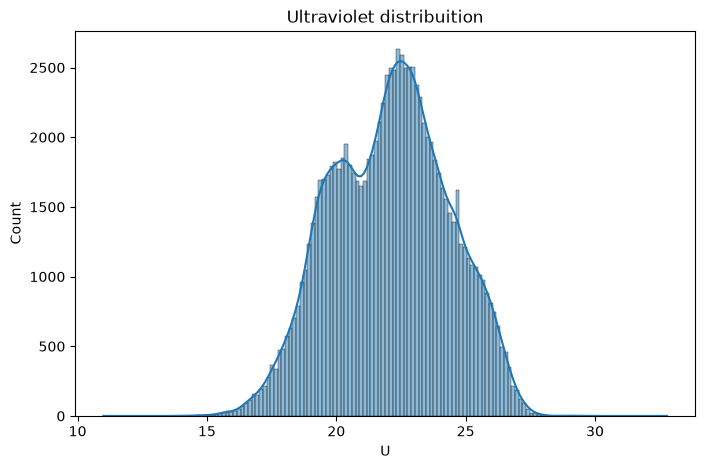

In [15]:
plot_histogram(
    data=analysis_df, x="u", title="Ultraviolet distribuition", grid=False, kde=True
)

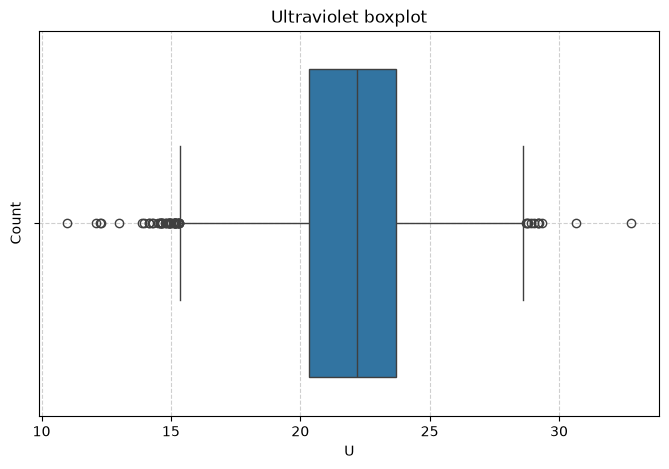

In [16]:
plot_box(data=analysis_df, x="u", title="Ultraviolet boxplot")

Conclusions:

- The range is from 10.99 to 32.78.
- The values are concentrated in the 20 < `u` < 24 range.
- It appears to be approximately symmetric.
- No clear outliers were observed visually.

#### g - Green filter:

In [17]:
analysis_df["g"].describe()

count    99999.000000
mean        20.631583
std          2.037384
min         10.498200
25%         18.965240
50%         21.099930
75%         22.123775
max         31.602240
Name: g, dtype: float64

In [18]:
analysis_df["g"].skew()

np.float64(-0.42803726053348284)

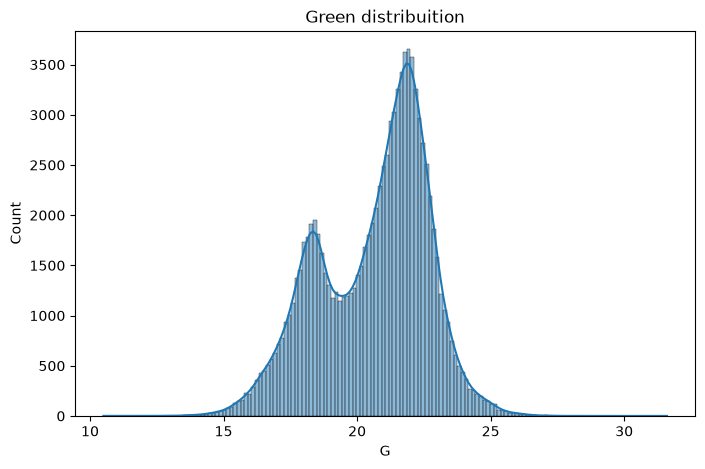

In [19]:
plot_histogram(
    data=analysis_df, x="g", title="Green distribuition", grid=False, kde=True
)

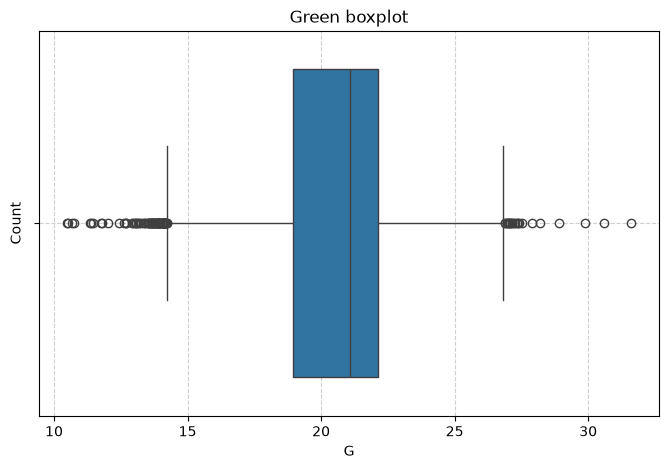

In [20]:
plot_box(data=analysis_df, x="g", title="Green boxplot")

Conclusions:

- The range is from 10.49 to 31.60.
- The values are concentrated in the 18 < `g` < 23 range.
- The distribution shows a slight left skew.
- No clear outliers were observed visually.

#### r - Red filter:

In [21]:
analysis_df["r"].describe()

count    100000.000000
mean         19.645762
std           1.854760
min           9.822070
25%          18.135828
50%          20.125290
75%          21.044785
max          29.571860
Name: r, dtype: float64

In [22]:
analysis_df["r"].skew()

np.float64(-0.5078584323335761)

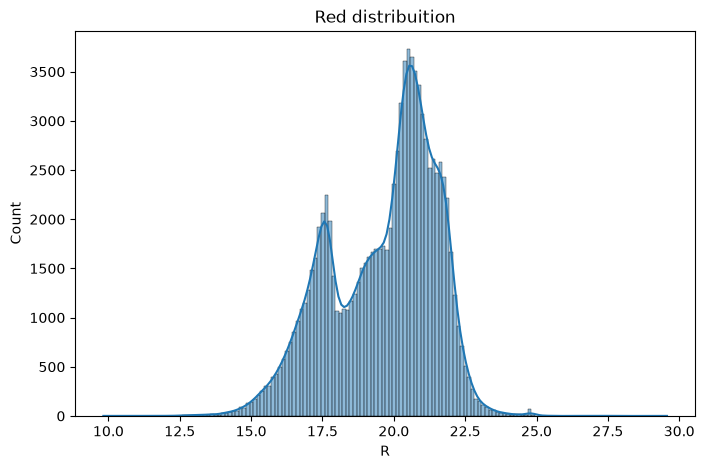

In [23]:
plot_histogram(data=analysis_df, x="r", title="Red distribuition", grid=False, kde=True)

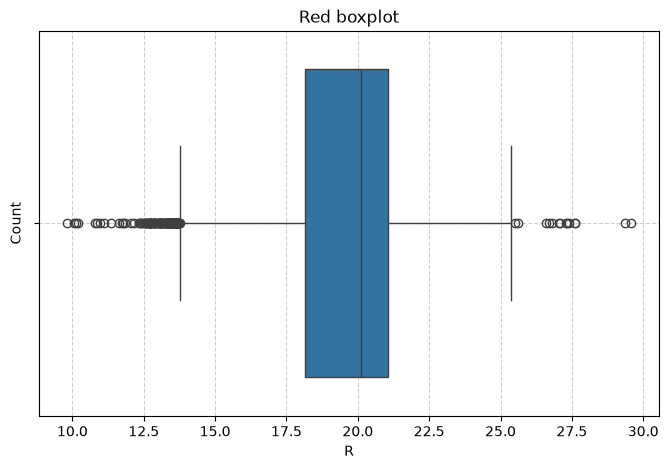

In [24]:
plot_box(data=analysis_df, x="r", title="Red boxplot")

Conclusions:

- The range is from 9.82 to 29.57.
- The values are concentrated in the 17 < `r` < 22 range.
- The distribution shows a slight left skew.
- No clear outliers were observed visually.

#### i - Near infrared filter:

In [25]:
analysis_df["i"].describe()

count    100000.000000
mean         19.084854
std           1.757895
min           9.469903
25%          17.732285
50%          19.405145
75%          20.396495
max          32.141470
Name: i, dtype: float64

In [26]:
analysis_df["i"].skew()

np.float64(-0.40416673966779565)

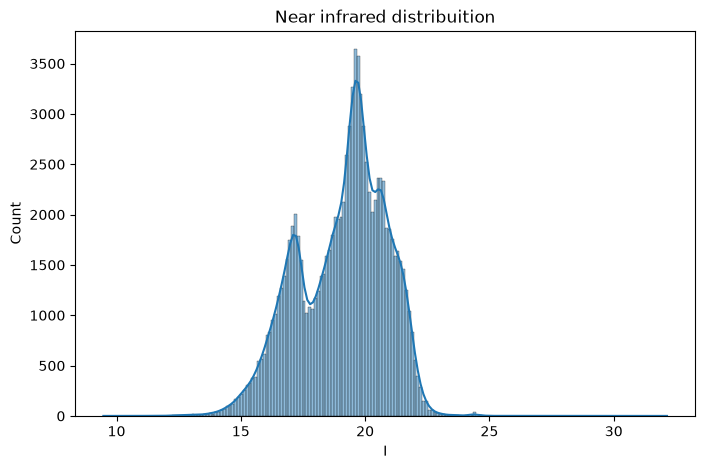

In [27]:
plot_histogram(
    data=analysis_df, x="i", title="Near infrared distribuition", grid=False, kde=True
)

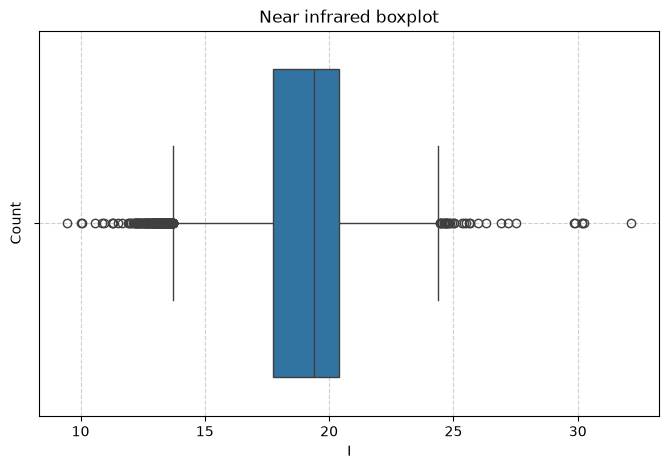

In [28]:
plot_box(data=analysis_df, x="i", title="Near infrared boxplot")

Conclusions:

- The range is from 9.46 to 32.14.
- The values are concentrated in the 17 < `i` < 21 range.
- The distribution shows a slight left skew.
- No clear outliers were observed visually.

#### z - Infrared filter:

In [29]:
analysis_df["z"].describe()

count    99999.000000
mean        18.768988
std          1.765982
min          9.612333
25%         17.460830
50%         19.004600
75%         19.921120
max         29.383740
Name: z, dtype: float64

In [30]:
analysis_df["z"].skew()

np.float64(-0.25682184022151566)

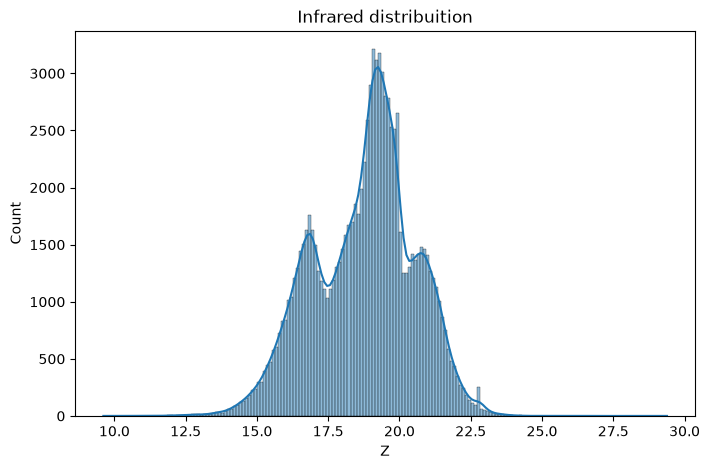

In [31]:
plot_histogram(
    data=analysis_df, x="z", title="Infrared distribuition", grid=False, kde=True
)

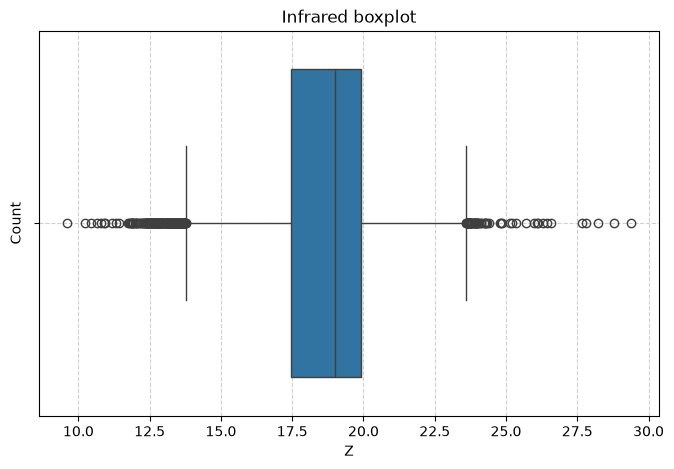

In [32]:
plot_box(data=analysis_df, x="z", title="Infrared boxplot")

Conclusions:

- The range is from 9.61 to 29.38.
- The values are concentrated in the 16 < `z` < 20 range.
- The distribution shows a slight left skew.
- No clear outliers were observed visually.

### 4.2.2 Redshift

In astronomy redshift is the streching of light waves to longer, redder wavelenghts as they travel through space. Redshift values are used to calculate how far away galaxies, quasar are.

How is redshift distributed?

In [33]:
analysis_df["redshift"].describe()

count    100000.000000
mean          0.576661
std           0.730707
min          -0.009971
25%           0.054517
50%           0.424173
75%           0.704154
max           7.011245
Name: redshift, dtype: float64

In [34]:
analysis_df["redshift"].skew()

np.float64(2.52360633103404)

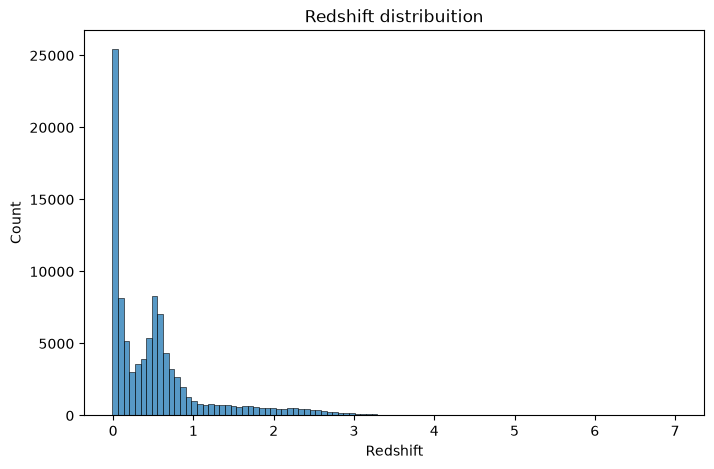

In [35]:
plot_histogram(
    data=analysis_df,
    x="redshift",
    title="Redshift distribuition",
    grid=False,
    kde=False,
    bins=100,
)

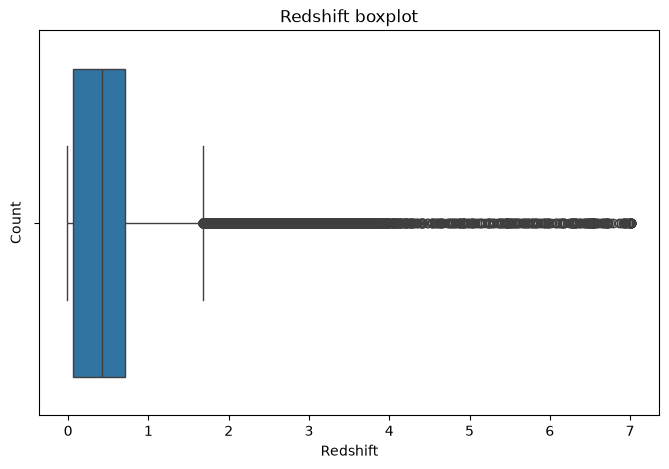

In [36]:
plot_box(data=analysis_df, x="redshift", title="Redshift boxplot", grid=False)

#### Conclusions about redshift:

- Redshift values are mainly concentrated in the 0 < `redshift` < 0.8 range.
- Median (approximately 0.42) and mean (0.57) showing asymmetry. 
- It has a tail to the right, observed mostly in the `skew()` with the value of 2.5, and in the boxplot graph.
- The graph has many outlier values between approximately 1.7 to 7.

## 4.3 Bivariate Analysis

In a bivariate analysis the question that need an answer is: "What is the relation between two variables?".

### 4.3.1 Numerical Relationship

In [37]:
corr = analysis_df[["u", "g", "r", "i", "z", "redshift"]].corr()

<Axes: >

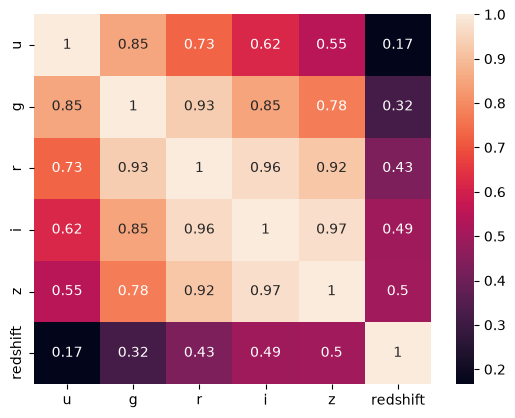

In [38]:
sns.heatmap(corr, annot=True)

Conclusions:

- The strongest positive relationships (corr > 0.90) are between: `i` and `r`; `z` and `i`; `r` and `g`; `z` and `r`.
- The variables that made the strongest relationship (0.42 < corr < 0.51 with `redshift` are: `z`, `i` and `r`.

### 4.3.2 Variables vs Target

#### Class vs Redshift

The questions that need to be answered in this analysis:

- Does any class occupy a clearly different region?
- Is there significant overlap between the classes?

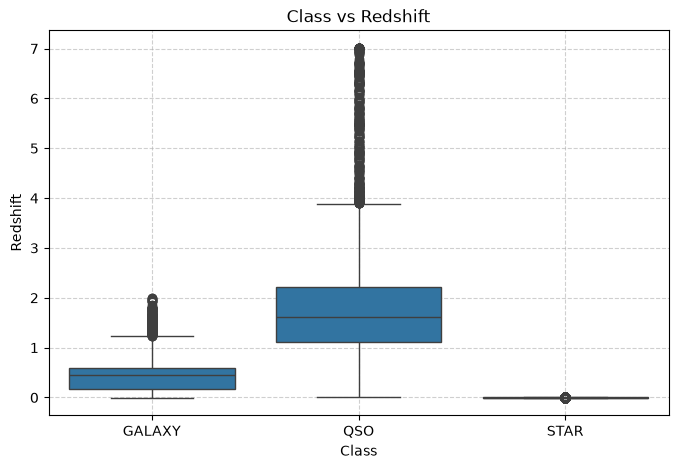

In [39]:
plot_box(
    data=analysis_df,
    x="class",
    y="redshift",
    title="Class vs Redshift",
    ylabel="Redshift",
)

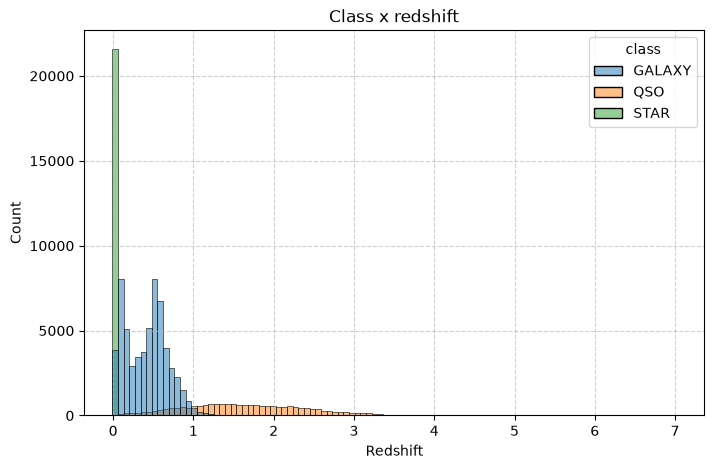

In [40]:
plot_histogram(
    data=analysis_df,
    x="redshift",
    title="Class x redshift",
    kde=False,
    hue="class",
    bins=100,
)

Conclusions:

- The star class are totally concentrated in the positives near zero region.
- The galaxies class are concentrated in a range from 0 to approximately 1.
- The quasar class are scattered between 0 and approximately 3.2.
- The classes slightly overlaps eachother, mainly the galaxies that are in the same region that stars are.

#### Class vs Photometric values

The questions that need to be answered in this analysis:

- Do the medians differ between classes?
- Do the distributions differ?
- Does any class occupy a clearly different region?
- Is there significant overlap between the classes?
- Which variable appears to have the greatest visual discriminative power?

#####  u x class:

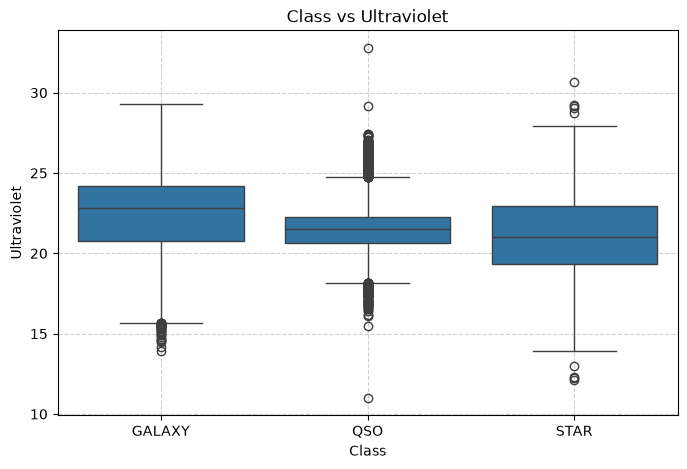

In [41]:
plot_box(
    data=analysis_df,
    x="class",
    y="u",
    title="Class vs Ultraviolet",
    ylabel="Ultraviolet",
)

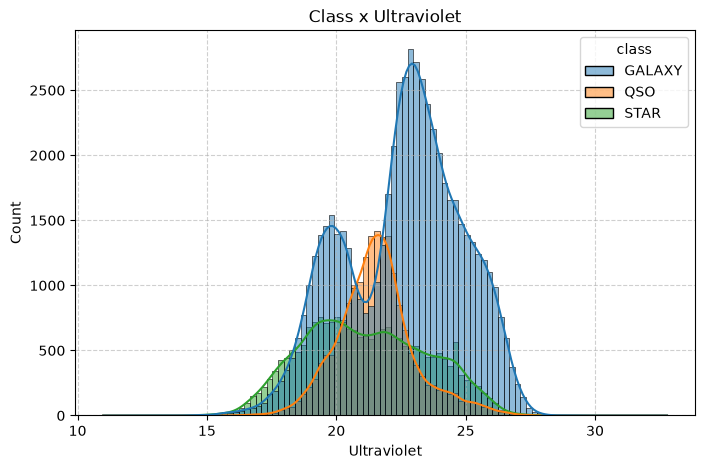

In [42]:
plot_histogram(
    data=analysis_df,
    x="u",
    title="Class x Ultraviolet",
    xlabel="Ultraviolet",
    kde=True,
    hue="class",
    bins=100,
)

Conclusions:

- The median between classes differ. Galaxy (≈22.6); Quasar (≈21.5); Star (≈21.0).
- Galaxies appears to be the class with the greatest visual discriminative power, while stars and quasar do not differ to much from each other their only diferrence is quasar being more concentrated and star more spread out.
- All classes appears to be concentrated in the same ultraviolet range (16 < `u` < 26). Therefore they overlap each other in this range.

##### g x class:

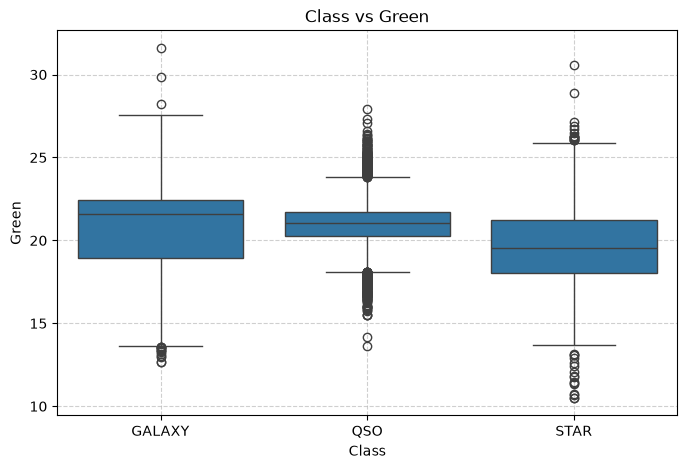

In [43]:
plot_box(data=analysis_df, x="class", y="g", title="Class vs Green", ylabel="Green")

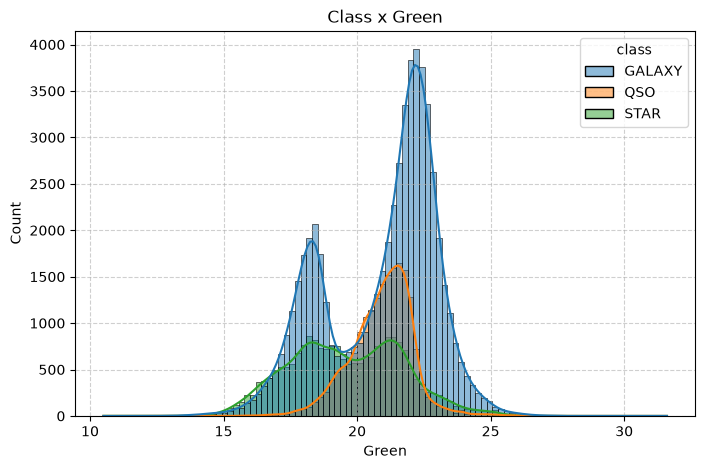

In [44]:
plot_histogram(
    data=analysis_df,
    x="g",
    title="Class x Green",
    xlabel="Green",
    kde=True,
    hue="class",
    bins=100,
)

Conclusions

- The median between classes differ. Galaxy (≈22.0); Quasar (≈21.0); Star (≈19.6).
- Galaxies, again, appears to be the class with the greatest visual discriminative power. Stars and quasar appears to be almost totally overlap by galaxies.
- All classes appears to be concentrated in the same green range (15 < `g` < 25).

##### r x class:

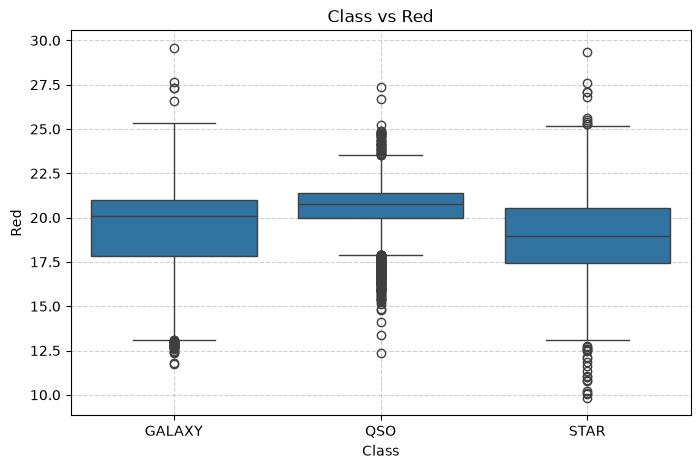

In [45]:
plot_box(data=analysis_df, x="class", y="r", title="Class vs Red", ylabel="Red")

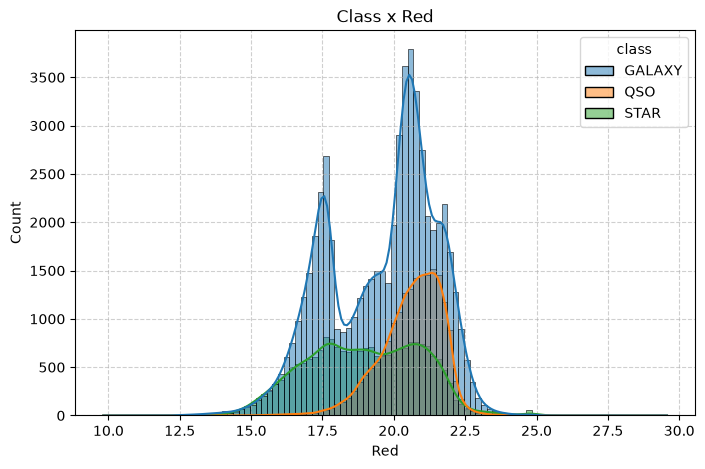

In [46]:
plot_histogram(
    data=analysis_df,
    x="r",
    title="Class x Red",
    xlabel="Red",
    kde=True,
    hue="class",
    bins=100,
)

Conclusions:

- The median between classes differ. Galaxy (≈20.0); Quasar (≈21.0); Star (≈18.9).
- Galaxies, again, appears to be the class with the greatest visual discriminative power. Stars and quasar appears to be almost totally overlap by galaxies.
- All classes appears to be concentrated in the same red range (15 < `r` < 23).

##### i x class:

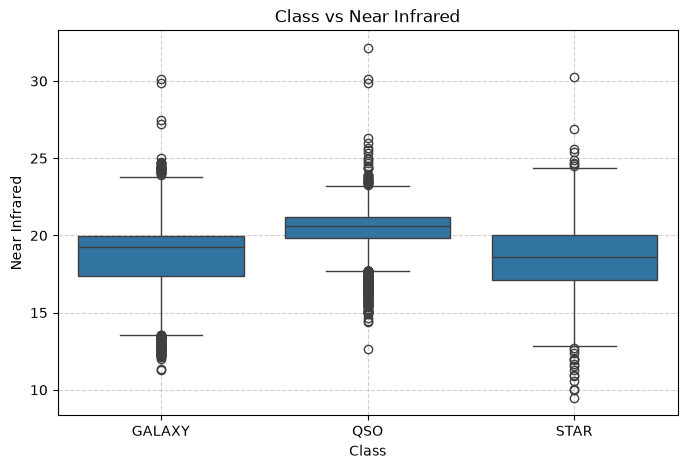

In [47]:
plot_box(
    data=analysis_df,
    x="class",
    y="i",
    title="Class vs Near Infrared",
    ylabel="Near Infrared",
)

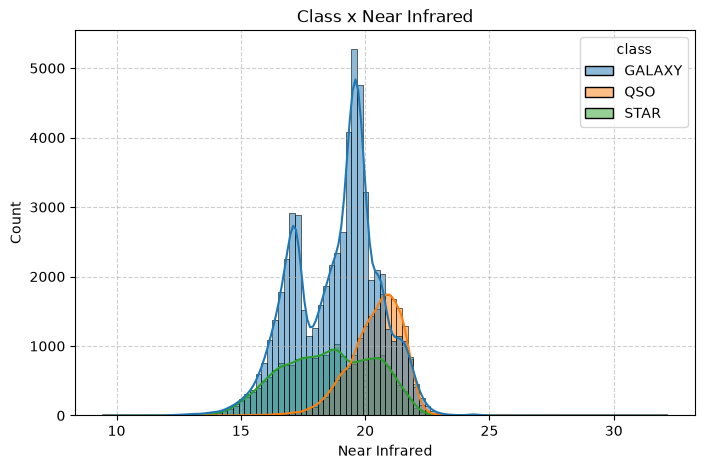

In [48]:
plot_histogram(
    data=analysis_df,
    x="i",
    title="Class x Near Infrared",
    xlabel="Near Infrared",
    kde=True,
    hue="class",
    bins=100,
)

Conclusions:

- The median between classes differ. Galaxy (≈19.2); Quasar (≈20.2); Star (≈18.0).
- Galaxies appears to be the class with the greatest visual discriminative power. Stars and quasar appears to be almost totally overlap by galaxies.
- All classes appears to be concentrated in the same near infrared range (15 < `i` < 23).

##### z x class:

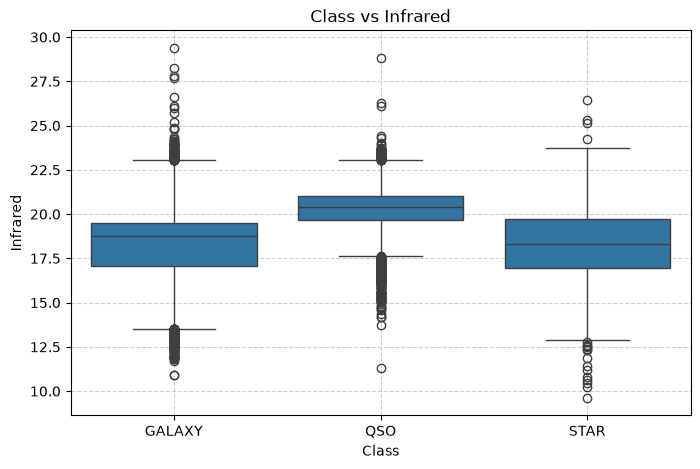

In [49]:
plot_box(
    data=analysis_df, x="class", y="z", title="Class vs Infrared", ylabel="Infrared"
)

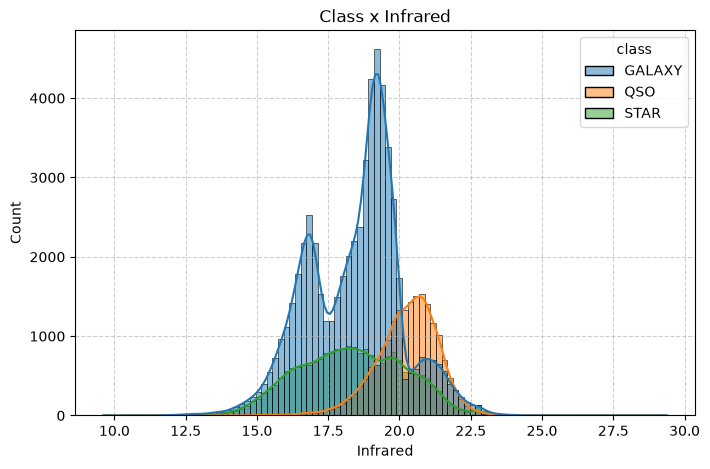

In [50]:
plot_histogram(
    data=analysis_df,
    x="z",
    title="Class x Infrared",
    xlabel="Infrared",
    kde=True,
    hue="class",
    bins=100,
)

Conclusions:

- The median between classes differ. Galaxy (≈19.0); Quasar (≈20.2); Star (≈18.2).
- Galaxies appears to be the class with the greatest visual discriminative power. Stars appears to be almost totally overlap by galaxies while quasar in areas with more infrared stands out.
- All classes appears to be concentrated in the same near infrared range (14 < `z` < 23).

### 4.4 Multivariate Analysis

When analyzing many variables simultaneously, does exist a pattern that was not so evident in the univariable and bivariable analysis?

#### 4.4.1 Pairwise relationships

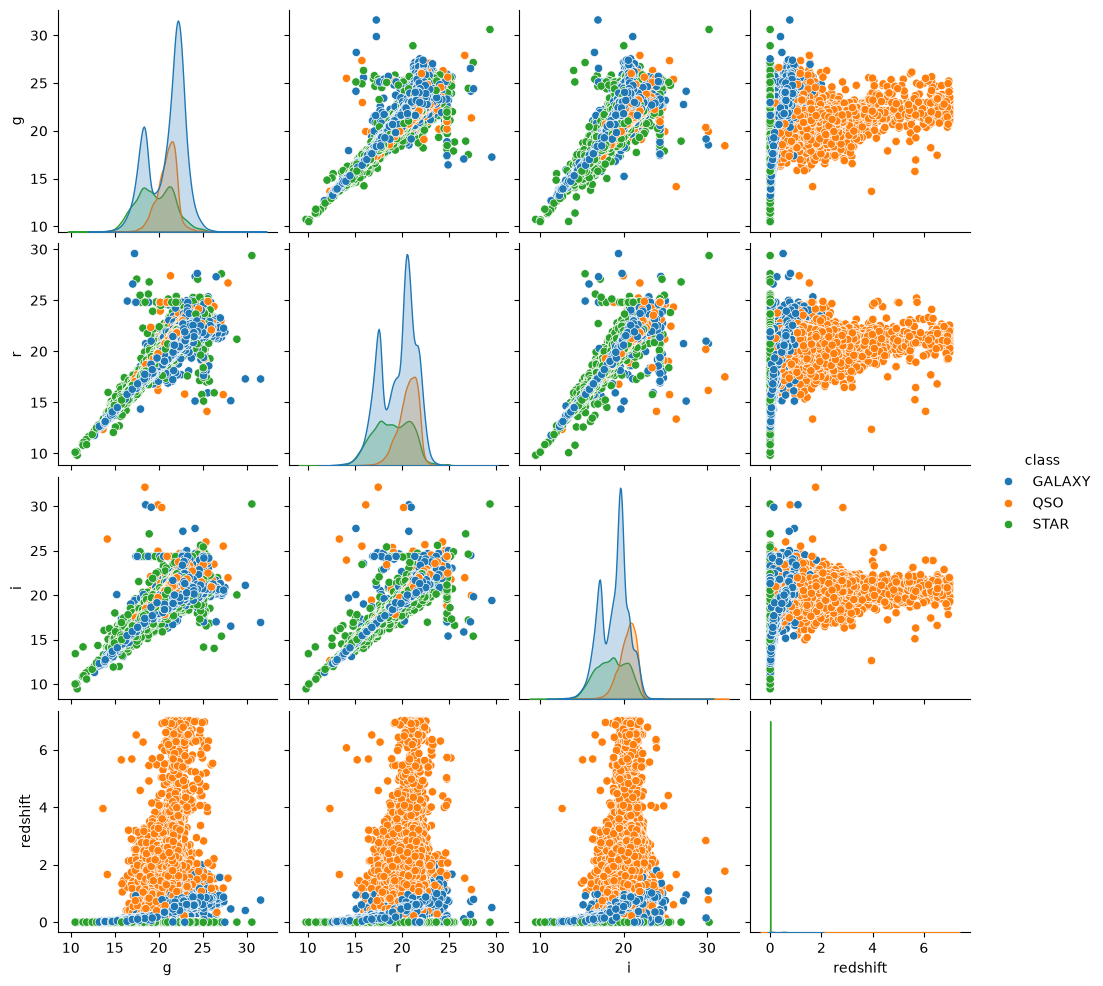

In [52]:
sns.pairplot(data=analysis_df[["g", "r", "i", "redshift", "class"]], hue="class")

#### 4.4.2 Multivariate Class Separation

<Axes: xlabel='g', ylabel='redshift'>

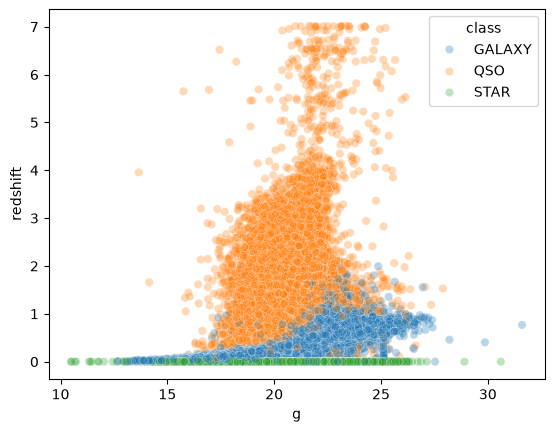

In [57]:
sns.scatterplot(data=analysis_df, x="g", y="redshift", hue="class", alpha=0.3)

#### 4.4.3 Main Findings

Conclusions:

- When it comes to redshift, quasar appears to be the class with the greatest visual discriminative power, while star is almost a line and galaxy is not as outstanding as quasar
- Probably the best way to differ classes are using redsfhit, as star contains almost 0, contains the biggest value and galaxies are in the first 1/4 of redshift.

# 5. Final Conclusions

- The columns that will be used in the processed data are the ones who contains the photometric values (`u`, `g`, `r`, `i` and `z`), the `redshfit` and the target `class`. These variables directly represent the measurements relevant to the classification task.
- The only cleaning needed in the data is to replace the sentinel values `-9999` from `u`, `g` and `z` for a `np.nan` as they are outside the expected range.
- The best relationship to classify appears to be the relation using a `redshift` value.
- Relations between photometric values appears to be not as good because almost the three classes overlap eachother.